In [12]:
%%javascript
IPython.notebook.kernel.execute('nb_name = "' + IPython.notebook.notebook_name + '"')

<IPython.core.display.Javascript object>

In [2]:
%load_ext autoreload
%autoreload 2
import os
import math
import time
import operator
import datetime
import h5py
from tqdm import tqdm
import wandb
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.image as image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset
import torchvision

import sys
sys.path.append('../../../helper_functions/')
from visualization_functions import show_images

def list_to_dict(lst):
    dictionary = {}
    for index, item in enumerate(lst):
        dictionary[index] = item
    return dictionary

def viz_dataloader(dl, n=8, hist=True, label_converter=None):
    batch = next(iter(dl))
    if len(batch[0]) < n: 
        raise ValueError("n is smaller than batch size, increase n")
    inputs = batch[0][:n]
    labels = list(batch[1][:n].numpy())
    if label_converter:
        for i in range(len(labels)):
            labels[i] = label_converter[labels[i]]
    show_images(torch.permute(inputs, [0,2,3,1]).cpu().numpy(), labels=labels, hist_bins=100)            

class hdf5_dataset(Dataset):
    
    def __init__(self, file_path, folder='train', transform=None, classes=[]):
        self.file_path = file_path
        self.folder = folder
        self.transform = transform
        self.hf = None

    def __len__(self):
        with h5py.File(self.file_path, 'r') as f:
            self.len = len(f[self.folder]['labels'])
        return self.len
    
    def __getitem__(self, idx):
        if self.hf is None:
            self.hf = h5py.File(self.file_path, 'r')
        
        image = np.array(self.hf[self.folder]['data'][idx])
        labels = np.array(self.hf[self.folder]['labels'][idx])
        
        if self.transform:
            image = self.transform(image)
        return image, labels

symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


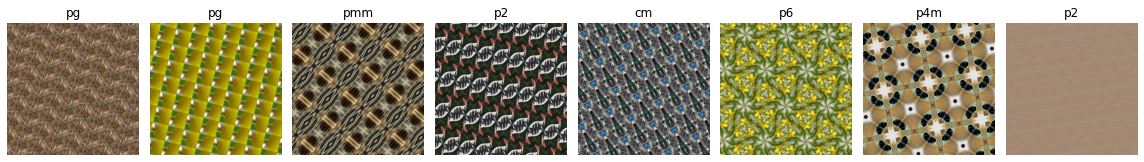

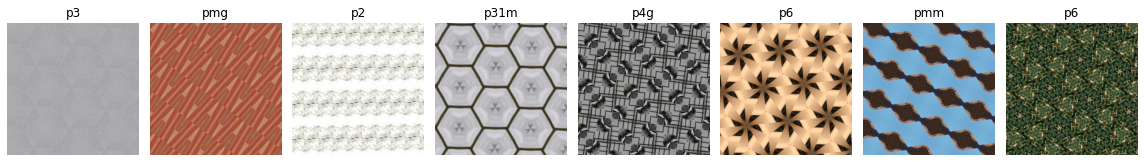

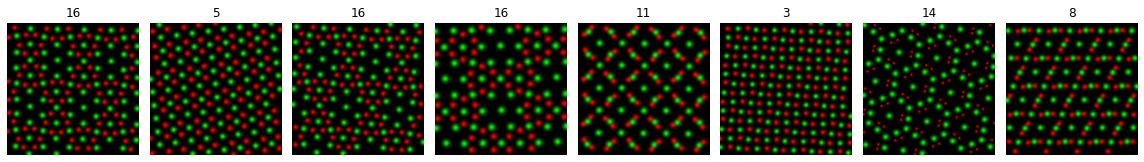

CPU times: user 25.9 s, sys: 1.22 s, total: 27.1 s
Wall time: 5.36 s


In [7]:
%%time
# imagenet
train_ds = hdf5_dataset('/scratch/yichen/imagenet_v4_rot_10m_5percent_subset.h5', folder='train', transform=transforms.ToTensor())
train_dl = DataLoader(train_ds, batch_size=200, shuffle=True, num_workers=6)
viz_dataloader(train_dl, label_converter=label_converter)

valid_ds = hdf5_dataset('/scratch/yichen/imagenet_v4_rot_10m_5percent_subset.h5', folder='valid', transform=transforms.ToTensor())
valid_dl = DataLoader(valid_ds, batch_size=200, shuffle=True, num_workers=6)
viz_dataloader(valid_dl, label_converter=label_converter)

test_ds = hdf5_dataset('/scratch/yichen/imagenet_v4_rot_10m_5percent_subset.h5', folder='test', transform=transforms.ToTensor())
test_dl = DataLoader(test_ds, batch_size=200, shuffle=True, num_workers=6)
viz_dataloader(test_dl)

In [5]:
from ae_customized import Autoencoder
model = Autoencoder()
out = model(torch.randn(2,3,256,256))
out[0].shape, out[1].shape

(torch.Size([2, 17]), torch.Size([2, 3, 256, 256]))

In [12]:
def train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, test_dl,
                 epochs, start=0, scheduler_imagenet=None, model_name=None, model_dir=None, tracking=False):

    # make directory for the model
    if model_dir and not os.path.isdir(model_dir): os.mkdir(model_dir)

    history = []
    
    if tracking:   
        wandb.watch(model, log_freq=100)
        
    for epoch_idx in range(start, epochs+start):
                
        print("Epoch: {}/{}".format(epoch_idx+1, epochs+start))
        
        avg_train_loss_mse, avg_train_loss_cross_entropy, avg_train_acc = train(model, loss_func, optimizer, device, train_dl,
                              scheduler_imagenet=scheduler_imagenet, tracking=tracking)
        
        avg_valid_loss_mse, avg_valid_loss_cross_entropy, avg_valid_acc = valid(model, loss_func, device, valid_dl, tracking=tracking)
        
        if test_dl:
            avg_test_loss_mse, avg_test_loss_cross_entropy, avg_test_acc = valid(model, loss_func, device, test_dl, tracking=tracking)
            
        if tracking:   
            # record the epoch loss and accuracy:            
            wandb.log({'epoch':epoch_idx, 
                        "train_loss_cross_entropy": avg_train_loss_cross_entropy,
                        "train_loss_mse": avg_train_loss_mse,
                        "train_acc": avg_train_acc, 

                        "valid_loss_cross_entropy": avg_valid_loss_cross_entropy,
                        "valid_loss_mse": avg_valid_loss_mse,
                        "valid_acc": avg_valid_acc,
                        
                        "test_loss_cross_entropy": avg_test_loss_cross_entropy,
                        "test_loss_mse": avg_test_loss_mse,
                        "test_acc": avg_test_acc})
                
        if model_name != None:
            torch.save(model, os.path.join(model_dir, model_name+'-epoch-{}.pt'.format(epoch_idx+1)))
                
    return history


def train(model, loss_func, optimizer, device, imagenet_dl, scheduler_imagenet=None, tracking=False):

    imagenet_data_size = len(imagenet_dl.dataset)

    # Set to training mode
    model.train()

    # Loss and Accuracy within the epoch
    train_acc = 0.0
    train_loss_cross_entropy = 0.0
    train_loss_mse = 0.0

    # imagenet dataset: cross entropy loss + MSE loss
    for i, batch in enumerate(tqdm(imagenet_dl)):
        inputs = batch[0].to(device).float()
        labels = batch[1].to(device).long()
        model = model.to(device)

        # Clean existing gradients
        optimizer.zero_grad()

        # Forward pass - compute outputs on input data using the model
        outputs, reconstructions = model(inputs)

        # Compute loss
        loss_cross_entropy = loss_func(outputs, labels)
        loss_mse = nn.MSELoss()(reconstructions, inputs) 
        loss = loss_cross_entropy + loss_mse

        # Compute the accuracy
        ret, predictions = torch.max(outputs.data, 1)
        correct_counts = predictions.eq(labels.data.view_as(predictions))

        # Convert correct_counts to float and then compute the mean
        acc = torch.mean(correct_counts.type(torch.FloatTensor))

        # Backpropagate the gradients
        loss.backward()

        # Update the parameters
        optimizer.step()
        if scheduler_imagenet:
            scheduler_imagenet.step()
        
        # Compute the total loss for the batch and add it to train_loss
        train_loss_cross_entropy += loss_cross_entropy.item() * inputs.size(0)
        train_loss_mse += loss_mse.item() * inputs.size(0)
        # Compute total accuracy in the whole batch and add to train_acc
        train_acc += acc.item() * inputs.size(0)
        
        if tracking:   
            wandb.log({'step':i, 
                        "train_loss_cross_entropy": train_loss_cross_entropy, 
                        "train_loss_mse": train_loss_mse})

    # Find average training loss and training accuracy
    avg_train_loss_cross_entropy = train_loss_cross_entropy/imagenet_data_size 
    avg_train_loss_mse = train_loss_mse/imagenet_data_size 
    avg_train_acc = train_acc/float(imagenet_data_size)
    print(f"Training: ImageNet MSE Loss: {avg_train_loss_mse:.4f}, Cross Entropy Loss: {avg_train_loss_cross_entropy:.4f}, Accuracy: {avg_train_acc*100:.4f}%")

    return avg_train_loss_mse, avg_train_loss_cross_entropy, avg_train_acc


def valid(model, loss_func, device, imagenet_dl, tracking=False):

    imagenet_data_size = len(imagenet_dl.dataset)

   # Loss and Accuracy within the epoch
    valid_acc = 0.0
    valid_loss_cross_entropy = 0.0
    valid_loss_mse = 0.0
    valid_loss_mse_atom = 0.0

    # imagenet dataset: cross entropy loss + MSE loss
    for i, batch in enumerate(tqdm(imagenet_dl)):
        inputs = batch[0].to(device).float()
        labels = batch[1].to(device).long()
        model = model.to(device)

        # Forward pass - compute outputs on input data using the model
        outputs, reconstructions = model(inputs)

        # Compute loss
        loss_cross_entropy = loss_func(outputs, labels)
        loss_mse = nn.MSELoss()(reconstructions, inputs) 
        loss = loss_cross_entropy + loss_mse

        # Compute the accuracy
        ret, predictions = torch.max(outputs.data, 1)
        correct_counts = predictions.eq(labels.data.view_as(predictions))

        # Convert correct_counts to float and then compute the mean
        acc = torch.mean(correct_counts.type(torch.FloatTensor))
     
        # Compute the total loss for the batch and add it to valid_loss
        valid_loss_cross_entropy += loss_cross_entropy.item() * inputs.size(0)
        valid_loss_mse += loss_mse.item() * inputs.size(0)
        # Compute total accuracy in the whole batch and add to valid_acc
        valid_acc += acc.item() * inputs.size(0)
        
        if tracking:   
            wandb.log({'step':i, 
                        "valid_loss_cross_entropy": valid_loss_cross_entropy, 
                        "valid_loss_mse": valid_loss_mse})

    # Find average validing loss and validing accuracy
    avg_valid_loss_cross_entropy = valid_loss_cross_entropy/imagenet_data_size 
    avg_valid_loss_mse = valid_loss_mse/imagenet_data_size 
    avg_valid_acc = valid_acc/float(imagenet_data_size)
    print(f"validing: ImageNet MSE Loss: {avg_valid_loss_mse:.4f}, Cross Entropy Loss: {avg_valid_loss_cross_entropy:.4f}, Accuracy: {avg_valid_acc*100:.4f}%")

    return avg_valid_loss_mse, avg_valid_loss_cross_entropy, avg_valid_acc

In [8]:
config = {
    'dataset': 'imagenet_v4_rot_10m_5percent_subset.h5',
    'device': torch.device('cuda:1'),
    'loss_func': 'CrossEntropyLoss and MSELoss' , # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
    'dropout': 0.5
}

NAME = '11092023-resnet_ae_semi-supervised-imagenet_only'

# train

In [9]:
# os.environ["WANDB_NOTEBOOK_NAME"] = nb_name
wandb.init(project='symmetry_paper', entity='yig319', name=NAME, id=NAME, save_code=True, config=config)
config = wandb.config

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yig319. Use `wandb login --relogin` to force relogin


In [13]:
device = config['device']
lr = 1e-3
start = 0
epochs = 50

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler_imagenet = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, test_dl,
                       epochs=epochs, start=start, scheduler_imagenet=scheduler_imagenet, model_name=NAME, 
                       model_dir='/scratch/yichen/models_new/', tracking=True)

Epoch: 1/50


  0%|          | 0/500 [00:00<?, ?it/s]

 15%|█▌        | 75/500 [00:40<03:41,  1.92it/s]

# analyze

In [7]:
model = torch.load('/scratch/yichen/models/05312023-benchmark-resnet50_from_scratch-v4_10m-epoch-19.pt')

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay

# imagenet 
def confusion_matrix(model, dataloader, classes, device, n_batches=1):
    model.eval()
    cm = torch.zeros(len(classes), len(classes))
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(tqdm(dataloader)):
            inputs = inputs.to(device) 
            labels = labels.to(device)
            model = model.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            for t, p in zip(labels.view(-1), preds.view(-1)):
                cm[t.long(), p.long()] += 1
    cm = np.array(cm)

    print('Sum for true labels:')
    true_counts = np.expand_dims(np.sum(cm, axis=1), 0)
    display(pd.DataFrame(true_counts, columns=classes))

    wrong, right = 0, 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if i == j: right+=cm[i,j]
            if i != j: wrong+=cm[i,j]
    print('Accuracy for these batches:', right/(right+wrong))
    return cm.astype(np.int32)

def plot_cm(cm, classes, save_file, title, style='simple'):

    if style == 'simple':
        fig = plt.figure(figsize=(12,10))
        ax = fig.subplots(1,1)
        ax.set_title('Confusion Matrix of'+title)

        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
        disp = disp.plot(cmap=plt.cm.Blues, ax=ax)

    if style== 'with_axis':
        df_cm = pd.DataFrame(cm)
        df_cm.index.name = 'Actual'
        df_cm.columns.name = 'Predicted'

        fig = plt.figure(figsize=(12,10))
        ax = fig.subplots(1,1)
        ax.set_title('Confusion Matrix of'+title)

        res = sn.heatmap(df_cm, annot=True, square=True, cmap='Blues',
                         xticklabels = classes, yticklabels=classes, fmt='g', 
                         ax=ax, cbar_kws={'label': 'Number of Images'})

        res.axhline(y = 0, color = 'k', 
                    linewidth = 1)
        res.axhline(y = 16.98, color = 'k',
                    linewidth = 1)
        res.axvline(x = 0, color = 'k',
                    linewidth = 1)
        res.axvline(x = 16.98, color = 'k',
                    linewidth = 1)
    
    if save_file: plt.savefig(save_file, dpi=300)
    plt.show()

NAME = 'benchmark-resnet50_from_scratch-v4_10m-05312023'
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                    'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']

In [9]:
device = torch.device('cuda:2')

cm = confusion_matrix(model, train_dl, symmetry_classes, device, n_batches='all')
np.save(NAME+'-train_cm.npy', cm)

100%|██████████| 43479/43479 [2:17:30<00:00,  5.27it/s]  


Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,588308.0,588239.0,588239.0,588233.0,588232.0,588231.0,588236.0,588232.0,588239.0,588237.0,588238.0,588239.0,588239.0,588224.0,588239.0,588238.0,588237.0


Accuracy for these batches: 0.9996354029167767


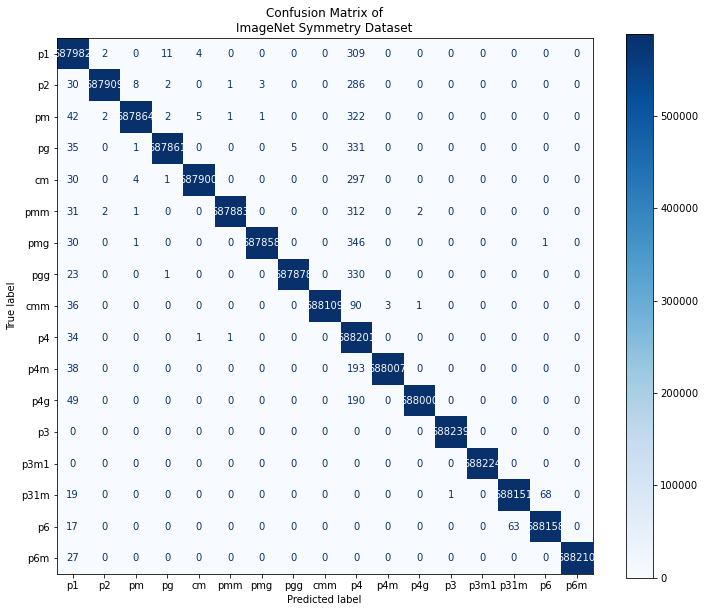

In [10]:
# cm = np.load('11172021-benchmark_atom-fpn_spatial-transfer_learning-train.npy')

plot_cm(cm, symmetry_classes, save_file=None, title='\nImageNet Symmetry Dataset', style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [11]:
cm = confusion_matrix(model, valid_dl, symmetry_classes, device, n_batches='all')
np.save(NAME+'-valid_cm.npy', cm)

100%|██████████| 8696/8696 [27:55<00:00,  5.19it/s]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,117670.0,117647.0,117647.0,117647.0,117646.0,117646.0,117648.0,117647.0,117647.0,117646.0,117647.0,117648.0,117647.0,117645.0,117645.0,117646.0,117647.0


Accuracy for these batches: 0.9991540067679459


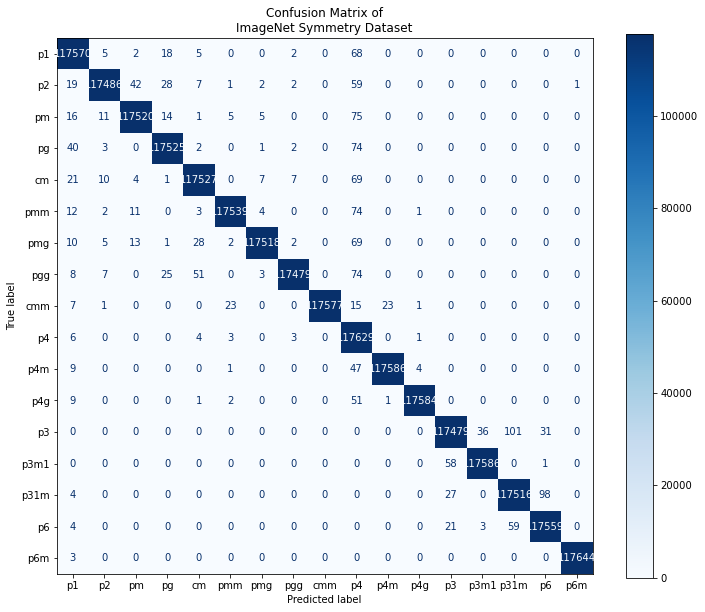

In [12]:
# cm = np.load('11172021-benchmark_imagenet-fpn_spatial-transfer_learning-valid.npy')

plot_cm(cm, symmetry_classes, save_file=None, title='\nImageNet Symmetry Dataset', style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [13]:
cm = confusion_matrix(model, test_dl, symmetry_classes, device, n_batches='all')
np.save(NAME+'-test_cm.npy', cm)

100%|██████████| 1985/1985 [29:26<00:00,  1.12it/s]


Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,270351.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0


Accuracy for these batches: 0.5805782531969523


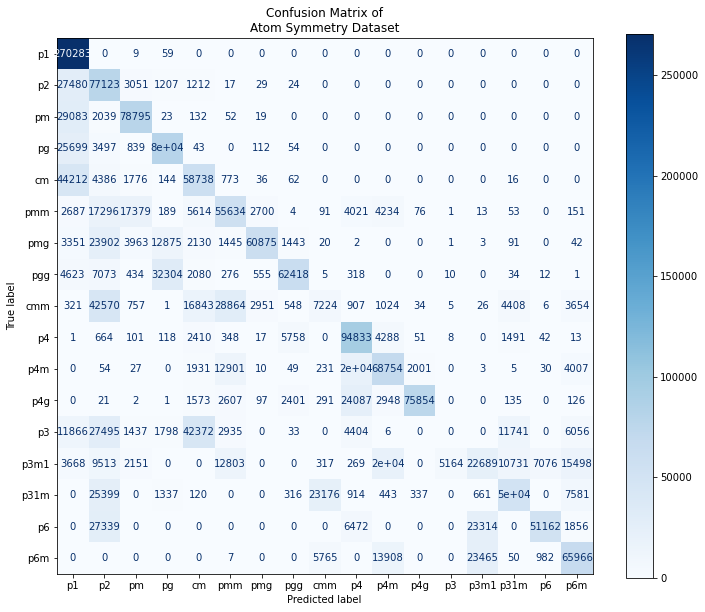

In [14]:
# cm = np.load('05232022-benchmark-resnet50_from_scratch-dataset_v3-test.npy')

plot_cm(cm, symmetry_classes, save_file=None, title='\nAtom Symmetry Dataset', style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [ ]:
import sys
sys.path.append('../../../helper_functions/')
from python_email import send_email
send_email()

In [ ]:
from IPython.display import display_html
def restartkernel() :
    display_html("<script>Jupyter.notebook.kernel.restart()</script>",raw=True)
restartkernel()